# BTC Market Analysis
Analisis faktor-faktor (macro, micro, siklus halving) yang mempengaruhi pergerakan harga Bitcoin, dengan tujuan memahami pola pergerakan pasar — bukan memprediksi harga secara presisi.

**Struktur notebook:**
1. Pengumpulan data harga
2. Feature engineering (siklus halving)
3. Data macro (suku bunga, dst)
4. Exploratory Data Analysis
5. Modeling (regime classification)

## 1. Import Libraries
`yfinance` untuk narik data harga BTC historis, `pandas` untuk manipulasi data tabular.

In [1]:
import yfinance as yf
import pandas as pd

## 2. Download Data Harga BTC
Ambil data harian BTC-USD dari Yahoo Finance mulai September 2014 (batas awal data yang tersedia gratis tanpa API key). Mencakup 3 siklus halving penuh (2016, 2020, 2024).

In [2]:
btc = yf.download("BTC-USD", start="2014-09-01", end=None)
btc = btc.reset_index()

[*********************100%***********************]  1 of 1 completed


## 3. Bersihkan Struktur Kolom
yfinance versi terbaru mengembalikan kolom dalam format MultiIndex meski cuma 1 ticker — diratakan supaya lebih mudah diproses di tahap selanjutnya.

In [3]:
btc.columns = btc.columns.get_level_values(0)
btc.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


## 4. Data Quality Check
Pastikan tidak ada nilai kosong (NaN) sebelum dipakai untuk analisis lebih lanjut.

In [4]:
btc.info()
btc.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4378 entries, 0 to 4377
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    4378 non-null   datetime64[s]
 1   Close   4378 non-null   float64      
 2   High    4378 non-null   float64      
 3   Low     4378 non-null   float64      
 4   Open    4378 non-null   float64      
 5   Volume  4378 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 205.3 KB


Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 5. Simpan ke CSV
Simpan hasil bersih ke `data/btc_price.csv` supaya tidak perlu narik ulang dari API tiap kali notebook dijalankan.

In [5]:
btc.to_csv("../data/btc_price.csv", index=False)

## 6. Visualisasi Awal
Plot harga dalam log scale (karena rentang harga BTC sangat lebar, dari puluhan dolar ke puluhan ribu) untuk lihat tren jangka panjang.

<Axes: title={'center': 'BTC Price History'}, xlabel='Date'>

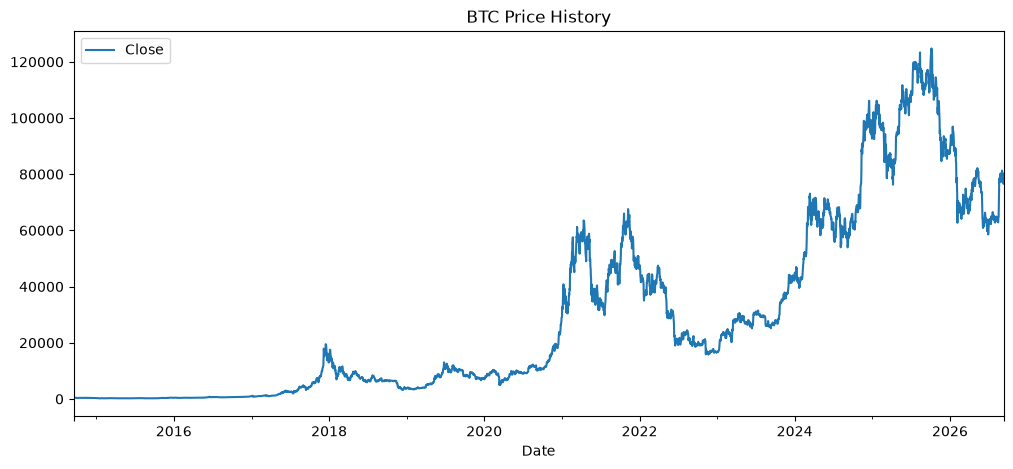

In [6]:
btc.plot(x="Date", y="Close", figsize=(12, 5), title="BTC Price History")

## 7. Tandai Siklus Halving
Tambahkan kolom jumlah hari sejak halving terakhir — dipakai nanti sebagai salah satu fitur untuk analisis pola siklus.

In [7]:
import datetime

halving_dates = [
    "2012-11-28",
    "2016-07-09",
    "2020-05-11",
    "2024-04-20"
]
halving_dates = [pd.to_datetime(d) for d in halving_dates]

def days_since_halving(date):
    past_halvings = [h for h in halving_dates if h <= date]
    if not past_halvings:
        return None
    last_halving = max(past_halvings)
    return (date - last_halving).days

btc["days_since_halving"] = btc["Date"].apply(days_since_halving)
btc.head()

Price,Date,Close,High,Low,Open,Volume,days_since_halving
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,658
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,659
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,660
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,661
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,662


## 8. Visualisasi dengan Marker Halving
Plot ulang harga BTC dengan garis vertikal di tiap tanggal halving, supaya bisa dilihat secara visual apakah ada pola pergerakan harga di sekitar event ini.

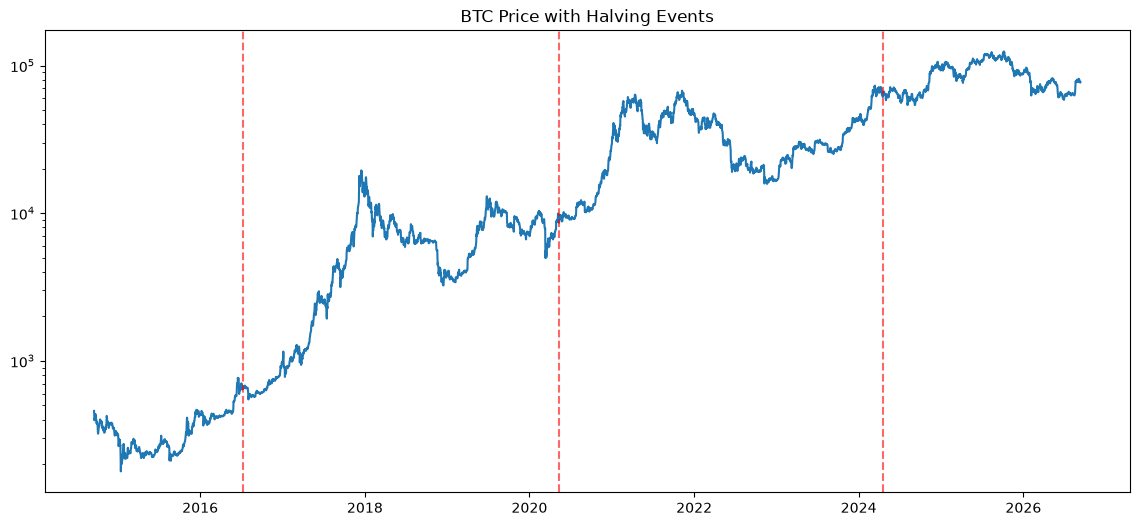

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc["Date"], btc["Close"])

for h in halving_dates:
    if h >= btc["Date"].min():
        ax.axvline(h, color="red", linestyle="--", alpha=0.6)

ax.set_title("BTC Price with Halving Events")
ax.set_yscale("log")  # log scale penting, karena range harga BTC dari puluhan ke puluhan ribu USD
plt.show()

## 9. Simpan Ulang Data dengan Kolom Halving
Update file CSV supaya menyertakan kolom `days_since_halving` yang baru ditambahkan, agar tidak perlu menghitung ulang setiap kali notebook dibuka.

In [9]:
btc.to_csv("../data/btc_price.csv", index=False)